# Fraud Detection with Polars (Lightning Fast!)

This notebook uses **Polars** instead of Dask. Polars is written in Rust and is significantly faster than Dask, especially for large datasets.

**Why Polars?**
- ✅ Pure Python (no Java required)
- ✅ **10-100x faster** than Pandas/Dask for large data
- ✅ Works in Jupyter seamlessly
- ✅ Built-in lazy evaluation & optimization
- ✅ Better memory efficiency
- ✅ Single pip install: `pip install polars`

## Step 1: Install Polars (One-time Setup)

In [1]:
!pip install polars-1.16.0-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl --no-index --find-links .

Looking in links: .
Processing ./polars-1.16.0-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
polars is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.


In [2]:
!pip install joblib-1.5.3-py3-none-any.whl --no-index --find-links .

Looking in links: .
Processing ./joblib-1.5.3-py3-none-any.whl
joblib is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.


In [3]:
!pip install threadpoolctl-3.6.0-py3-none-any.whl --no-index --find-links .

Looking in links: .
Processing ./threadpoolctl-3.6.0-py3-none-any.whl
threadpoolctl is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.


In [4]:
!pip install scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl --no-index --find-links .

Looking in links: .
Processing ./scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl
scikit-learn is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.


## Step 2: Import Libraries

In [5]:
import polars as pl
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc, precision_recall_curve,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score
)
import os
import itertools
import joblib
import logging
from typing import List, Dict, Any, Optional
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from google.oauth2 import service_account
import time

# Configure Logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

print("✅ All imports successful!")
print(f"Polars version: {pl.__version__}")

✅ All imports successful!
Polars version: 1.16.0


## Step 3: BigQuery Service

In [6]:
class BigQueryService:
    """Service for BigQuery operations"""
    def __init__(self, project_id="pgd-dev-data-analytics", sa_path='jupyter-pgd-prod-data-analytics-0fa0e01ee70a.json'):
        self.project_id = project_id
        self.sa_path = sa_path
        self.client = self._initialize_client()
    
    def _initialize_client(self):
        try:
            abs_sa_path = os.path.abspath(self.sa_path)
            if os.path.exists(abs_sa_path):
                credentials = service_account.Credentials.from_service_account_file(abs_sa_path)
                client = bigquery.Client(project=self.project_id, credentials=credentials)
                logger.info(f"Initialized BigQuery client using: {abs_sa_path}")
            else:
                logger.warning(f"Service account file not found at {abs_sa_path}, using default credentials")
                client = bigquery.Client(project=self.project_id)
            return client
        except Exception as e:
            logger.error(f"Failed to initialize client: {e}")
            raise
    
    def get_suspicious_customer_list(self) -> pd.DataFrame:
        query = "SELECT DISTINCT cif FROM `pgd-dev-data-analytics.datamart_audit.dm_det_tbl_fds_suspicious_summary` ORDER BY cif"
        try: 
            return self.client.query(query).to_dataframe()
        except Exception as e:
            logger.error(f"Error fetching suspicious list: {e}")
            return pd.DataFrame(columns=['cif'])
    
    def get_customer_list(self) -> pd.DataFrame:
        query = "SELECT DISTINCT cif FROM `pgd-dev-data-analytics.datamart_audit.dm_det_tbl_customer_fds` ORDER BY cif"
        try: 
            return self.client.query(query).to_dataframe()
        except Exception as e:
            logger.error(f"Error fetching customer list: {e}")
            return pd.DataFrame(columns=['cif'])

print("✅ BigQueryService class defined")

✅ BigQueryService class defined


## Step 4: Load Data with Polars

In [28]:
from datetime import date

# Get today's date
this_date = date.today()

In [9]:
def load_all_data(base_path, bq_service):
    """Load all data using Polars - ultra fast!"""
    logger.info("Loading data files with Polars...")
    start = time.time()
    
    tr_path = os.path.join(base_path, 'data_fds_evidence_graph_trx.csv')
    co_path = os.path.join(base_path, 'data_fds_evidence_graph_koneksi.csv')
    
    # Fallback paths
    if not os.path.exists(tr_path):
        tr_path = 'data_fds_evidence_graph_trx.csv'
        co_path = 'data_fds_evidence_graph_koneksi.csv'
    
    # Read CSVs with Polars (lazy evaluation for efficiency)
    tr = pl.scan_csv(tr_path, schema_overrides={
        "cif": pl.String, "kode_outlet": pl.String, "non_tunai":pl.Int64, "te":pl.Int64, "kredit":pl.Int64, "produk":pl.String , "up":pl.Float64, "cif_penerima": pl.String}, 
                     infer_schema_length=10000).collect()
    co = pl.scan_csv(co_path, schema_overrides={
        "cif": pl.String, "hp": pl.String,"no_rek_bank": pl.String,"ktp": pl.String, "nik": pl.String}, 
                     infer_schema_length=10000).collect()
    
    # Get BigQuery data
    su = bq_service.get_suspicious_customer_list()
    cu = bq_service.get_customer_list()
    
    logger.info(f"Transaction data shape: {tr.shape}")
    logger.info(f"Connection data shape: {co.shape}")
    
    return tr, co, su, cu

base = os.getcwd()
output_dir = os.path.join(base, 'unsupervised_polars_output')
os.makedirs(output_dir, exist_ok=True)

# Initialize BigQuery
bq = BigQueryService()
start = time.time()
t_df, c_df, s_df, cl_df = load_all_data(base, bq)
elapsed = time.time() - start

print(f"✅ Data loaded successfully in {elapsed:.2f}s")

INFO:__main__:Initialized BigQuery client using: /home/jupyterhub/work/SIDIK/jupyter-pgd-prod-data-analytics-0fa0e01ee70a.json
INFO:__main__:Loading data files with Polars...
/opt/conda/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
INFO:__main__:Transaction data shape: (25717335, 8)
INFO:__main__:Connection data shape: (9686434, 5)


✅ Data loaded successfully in 74.61s


## Step 5: Extract Transaction Features with Polars

In [12]:
t_df

cif,kode_outlet,non_tunai,te,kredit,produk,up,cif_penerima
str,str,i64,i64,i64,str,f64,str
"""1000000025""","""13321""",null,1332119620000211,null,null,2.483965e6,null
"""1000000025""","""13321""",null,1332119620000211,null,null,1.0999965e7,null
"""1000000025""","""13321""",null,1332119620000211,null,null,59529.0,null
"""1000000025""","""13321""",null,1332119620000211,null,null,65907.0,null
"""1000000025""","""13321""",null,1332119620000211,null,null,1e7,null
…,…,…,…,…,…,…,…
"""9100792821""","""60692""",null,null,6069226270000884,null,1.252985e7,null
"""9100792821""","""60697""",null,null,6069726020003286,null,3.25e6,null
"""9100792878""","""60283""",null,null,6028325020099129,null,6.85e6,null


In [13]:
def fix_trx_features(pl_df):
    """Extract transaction-based features using Polars (lightning fast)"""
    logger.info("Extracting transaction features with Polars...")
    start = time.time()
    
    # Fill nulls and convert up to numeric
    df = pl_df.with_columns([
        pl.col('up').fill_null(0).cast(pl.Float64)
    ])
    
    # Aggregate by cif (Polars groupby is blazing fast)
    feats = df.group_by('cif').agg([
        pl.col('up').sum().alias('up_sum'),
        pl.col('up').mean().alias('up_mean'),
        pl.col('up').max().alias('up_max'),
        pl.col('up').count().alias('up_count'),
        pl.col('produk').n_unique().alias('product_nunique')
    ]).sort('cif')
    
    # Convert back to pandas for compatibility
    feats_pd = feats.to_pandas()
    feats_pd['cif'] = feats_pd['cif'].astype(str)
    
    elapsed = time.time() - start
    logger.info(f"Extracted {len(feats_pd)} transaction features in {elapsed:.2f}s")
    return feats_pd

trx_feats = fix_trx_features(t_df)
all_cifs = trx_feats['cif'].values

print(f"✅ Transaction features extracted: {trx_feats.shape}")
print(trx_feats.head())

INFO:__main__:Extracting transaction features with Polars...
INFO:__main__:Extracted 8729054 transaction features in 12.53s


✅ Transaction features extracted: (8729054, 6)
          cif      up_sum       up_mean      up_max  up_count  product_nunique
0  1000000025  28639130.0  3.579891e+06  10999965.0         8                1
1  1000000031  69760000.0  6.341818e+06  16000000.0        11                2
2  1000000038   3000000.0  3.000000e+06   3000000.0         1                1
3  1000000040  63660000.0  9.094286e+06  15820000.0         7                1
4  1000000067  20980000.0  5.245000e+06   6650000.0         4                1


## Step 6: Extract Connection Features with Polars

In [15]:
def extract_connection_features(pl_df, cifs):
    """Extract connection-based features using Pure Polars (fully vectorized, 50-200x faster!)"""
    logger.info("Extracting connection features with Pure Polars (vectorized)...")
    start = time.time()
    
    # Cast cif to string
    df = pl_df.with_columns(pl.col('cif').cast(pl.Utf8))
    
    # Use pure Polars groupby aggregation (no pandas conversion needed!)
    result = df.group_by('cif').agg([
        pl.col('hp').drop_nulls().n_unique().alias('hp_count'),
        pl.col('no_rek_bank').drop_nulls().n_unique().alias('no_rek_bank_count'),
        pl.col('ktp').drop_nulls().n_unique().alias('ktp_count'),
        pl.col('nik').drop_nulls().n_unique().alias('nik_count')
    ]).with_columns(
        (pl.col('hp_count') + pl.col('no_rek_bank_count') + 
         pl.col('ktp_count') + pl.col('nik_count')).alias('total_connections')
    ).sort('cif')
    
    # Convert to pandas only at the end for compatibility
    result_pd = result.to_pandas()
    
    elapsed = time.time() - start
    logger.info(f"Extracted {len(result_pd)} connection features in {elapsed:.2f}s")
    return result_pd

conn_feats = extract_connection_features(c_df, all_cifs)

INFO:__main__:Extracting connection features with Pure Polars (vectorized)...
INFO:__main__:Extracted 9685822 connection features in 21.98s


## Step 7: Build Graph and Process Features

In [18]:
def make_graph(conn_df, cifs):
    """Construct CIF connection graph"""
    logger.info("Constructing CIF connection graph...")
    c2i = {c: i for i, c in enumerate(cifs)}
    n = len(cifs)
    cols = ['no_rek_bank', 'ktp', 'hp', 'nik']
    rows, cols_idx = [], []
    
    for c in cols:
        if c not in conn_df.columns:
            continue
        valid = conn_df[['cif', c]].dropna()
        valid = valid[~valid[c].astype(str).isin(["", "0", "\\N", "nan", "-"])]
        groups = valid.groupby(c)['cif'].apply(list)
        
        for g in groups:
            if 1 < len(g) <= 50:
                idxs = [c2i[x] for x in g if x in c2i]
                if len(idxs) < 2:
                    continue
                for u, v in itertools.permutations(idxs, 2):
                    rows.append(u)
                    cols_idx.append(v)
    
    if not rows:
        adj = sp.csr_matrix((n, n))
    else:
        adj = sp.coo_matrix((np.ones(len(rows)), (rows, cols_idx)), shape=(n, n)).tocsr()
    
    return adj + sp.eye(n), c2i

def do_gin_agg(adj, feat, layers=2):
    """GIN aggregation with sparse matrix ops"""
    logger.info(f"Running GIN aggregation ({layers} layers)...")
    x = feat
    out = x.copy()
    
    for i in range(layers):
        new_x = adj.dot(x)
        deg = np.array(adj.sum(axis=1)).flatten()
        deg[deg == 0] = 1
        d_inv = sp.diags(1.0 / deg)
        new_x = d_inv.dot(new_x)
        x = new_x
        out = np.concatenate([out, x], axis=1)
    
    return out

# Build graph
c_df_pd = c_df.to_pandas()
adj, c2i = make_graph(c_df_pd, all_cifs)

# **CRITICAL FIX**: Align connection features with transaction CIFs
# Handle CIFs that appear in transactions but not in connections (fill with 0s)
conn_feats['cif'] = conn_feats['cif'].astype(str)
conn_feats_indexed = conn_feats.set_index('cif')

# Reindex to match all_cifs, filling missing CIFs with 0s
conn_feats_aligned = conn_feats_indexed.reindex(all_cifs, fill_value=0).reset_index()

missing_count = (conn_feats_aligned.iloc[:, 1:].sum(axis=1) == 0).sum()
logger.info(f"Original conn_feats shape: {conn_feats.shape}, Aligned shape: {conn_feats_aligned.shape}")
logger.info(f"CIFs with zero connection features (filled): {missing_count}")
logger.info(f"Adjacency matrix shape: {adj.shape}")

# Process features with aligned data
conn_X_raw = StandardScaler().fit_transform(conn_feats_aligned.iloc[:, 1:].values)
conn_X_agg = do_gin_agg(adj, conn_X_raw)
trx_X_raw = StandardScaler().fit_transform(trx_feats.drop(columns=['cif']).values)

print(f"✅ Graph and features processed")
print(f"Connection features shape: {conn_X_agg.shape}")
print(f"Transaction features shape: {trx_X_raw.shape}")

INFO:__main__:Constructing CIF connection graph...
INFO:__main__:Original conn_feats shape: (9685822, 6), Aligned shape: (8729054, 6)
INFO:__main__:CIFs with zero connection features (filled): 1790084
INFO:__main__:Adjacency matrix shape: (8729054, 8729054)
INFO:__main__:Running GIN aggregation (2 layers)...


✅ Graph and features processed
Connection features shape: (8729054, 15)
Transaction features shape: (8729054, 5)


## Step 8: Prepare Target Labels

In [19]:
# Target values (only for evaluation, NOT training)
s_cifs = set(s_df['cif'].astype(str))
k_cifs = set(cl_df['cif'].astype(str))

y = np.full(len(all_cifs), -1)
for i, c in enumerate(all_cifs):
    if c in s_cifs:
        y[i] = 1
    elif c in k_cifs:
        y[i] = 0

logger.info(f"Target distribution: Fraud={np.sum(y==1)}, Non-Fraud={np.sum(y==0)}, Unknown={np.sum(y==-1)}")
print(f"✅ Target labels prepared")

INFO:__main__:Target distribution: Fraud=407757, Non-Fraud=5786394, Unknown=2534903


✅ Target labels prepared


## Step 9: Train Isolation Forest Models

In [20]:
logger.info("=" * 60)
logger.info("TRAINING ISOLATION FORESTS (ON ALL DATA)")
logger.info("=" * 60)

# Connection Model
print("Training Connection Model...")
start = time.time()
conn_clf = IsolationForest(n_estimators=200, random_state=42, n_jobs=-1, contamination='auto')
conn_clf.fit(conn_X_agg)
conn_all_p = -conn_clf.score_samples(conn_X_agg)
conn_pred_labels = conn_clf.predict(conn_X_agg)
print(f"✅ Connection Model trained in {time.time()-start:.2f}s")

# Transaction Model
print("Training Transaction Model...")
start = time.time()
trx_clf = IsolationForest(n_estimators=200, random_state=42, n_jobs=-1, contamination='auto')
trx_clf.fit(trx_X_raw)
trx_all_p = -trx_clf.score_samples(trx_X_raw)
trx_pred_labels = trx_clf.predict(trx_X_raw)
print(f"✅ Transaction Model trained in {time.time()-start:.2f}s")

# Normalize scores
scaler_conn = MinMaxScaler().fit(conn_all_p.reshape(-1, 1))
scaler_trx = MinMaxScaler().fit(trx_all_p.reshape(-1, 1))

conn_norm_p = scaler_conn.transform(conn_all_p.reshape(-1, 1)).flatten()
trx_norm_p = scaler_trx.transform(trx_all_p.reshape(-1, 1)).flatten()
combined_norm_p = (conn_norm_p + trx_norm_p) / 2

print(f"✅ Scores normalized")

INFO:__main__:============================================================
INFO:__main__:TRAINING ISOLATION FORESTS (ON ALL DATA)
INFO:__main__:============================================================


Training Connection Model...
✅ Connection Model trained in 116.84s
Training Transaction Model...
✅ Transaction Model trained in 178.83s
✅ Scores normalized


## Step 10: Compute Metrics and Save Results

In [21]:
def get_supervised_metrics(y_true, y_prob, thresh=None):
    if thresh is None:
        best_f1, best_t = -1, y_prob.min()
        if y_prob.min() < y_prob.max():
            thresholds = np.linspace(y_prob.min(), y_prob.max(), 100)
            for t in thresholds:
                f1 = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
                if f1 > best_f1:
                    best_f1, best_t = f1, t
        thresh = best_t

    y_pred = (y_prob >= thresh).astype(int)
    auc_score = roc_auc_score(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    rec = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    k = int(np.sum(y_true == 1))
    reck = np.sum(y_true[np.argsort(y_prob)[-k:]] == 1) / k if k > 0 else 0.0
    
    return {
        'auc': auc_score, 'ap': ap, 'prec': prec, 'rec': rec,
        'f1': f1, 'reck': reck, 'threshold': thresh
    }

def get_unsupervised_metrics(X, preds, model_name="model"):
    metrics = {}
    if len(np.unique(preds)) > 1:
        metrics['silhouette'] = silhouette_score(X, preds, sample_size=10000, random_state=42)
        metrics['calinski_harabasz'] = calinski_harabasz_score(X, preds)
        metrics['davies_bouldin'] = davies_bouldin_score(X, preds)
    else:
        metrics['silhouette'] = 0.0
        metrics['calinski_harabasz'] = 0.0
        metrics['davies_bouldin'] = 0.0
    
    logger.info(f"{model_name} Unsupervised Metrics - Silhouette: {metrics['silhouette']:.4f}, "
                f"CH Index: {metrics['calinski_harabasz']:.4f}, DB Index: {metrics['davies_bouldin']:.4f}")
    return metrics

# Compute unsupervised metrics
conn_unsup_metrics = get_unsupervised_metrics(conn_X_agg, conn_pred_labels, "Connection Model")
trx_unsup_metrics = get_unsupervised_metrics(trx_X_raw, trx_pred_labels, "Transaction Model")

# Compute supervised metrics (on labeled subset)
labeled = np.where(y != -1)[0]
y_test = y[labeled]
conn_test_p = conn_norm_p[labeled]
trx_test_p = trx_norm_p[labeled]
comb_test_p = combined_norm_p[labeled]

conn_sup_res = get_supervised_metrics(y_test, conn_test_p)
trx_sup_res = get_supervised_metrics(y_test, trx_test_p)
comb_sup_res = get_supervised_metrics(y_test, comb_test_p)

print(f"\n✅ Connection Model - AUC: {conn_sup_res['auc']:.4f}, AP: {conn_sup_res['ap']:.4f}")
print(f"✅ Transaction Model - AUC: {trx_sup_res['auc']:.4f}, AP: {trx_sup_res['ap']:.4f}")
print(f"✅ Combined Model - AUC: {comb_sup_res['auc']:.4f}, AP: {comb_sup_res['ap']:.4f}")

INFO:__main__:Connection Model Unsupervised Metrics - Silhouette: 0.9876, CH Index: 25457595.0543, DB Index: 0.1056
INFO:__main__:Transaction Model Unsupervised Metrics - Silhouette: 0.6694, CH Index: 1169113.2401, DB Index: 1.5212



✅ Connection Model - AUC: 0.4534, AP: 0.0628
✅ Transaction Model - AUC: 0.6405, AP: 0.1434
✅ Combined Model - AUC: 0.5682, AP: 0.0836


## Step 11: Export Results

In [22]:
# Create results DataFrame
pred_df = pd.DataFrame({
    'cif': all_cifs,
    'connection_score_raw': conn_all_p,
    'transaction_score_raw': trx_all_p,
    'connection_proba_norm': conn_norm_p,
    'transaction_proba_norm': trx_norm_p,
    'combined_proba': combined_norm_p,
    'connection_pred': (conn_norm_p >= conn_sup_res['threshold']).astype(int),
    'transaction_pred': (trx_norm_p >= trx_sup_res['threshold']).astype(int),
    'combined_pred': (combined_norm_p >= comb_sup_res['threshold']).astype(int),
    'real_label': y
})

# Filter for suspected fraud
pred_df_fraud = pred_df[(pred_df['connection_proba_norm'] > 0.5) & (pred_df['transaction_proba_norm'] > 0.5)]

# Save results using Polars for speed
pred_polars = pl.from_pandas(pred_df)
pred_fraud_polars = pl.from_pandas(pred_df_fraud)

pred_polars.write_csv(os.path.join(output_dir, f'unsupervised_polars_predictions_all_{this_date}.csv'))
pred_fraud_polars.write_csv(os.path.join(output_dir, f'unsupervised_polars_predictions_fraud_only_{this_date}.csv'))

# Save models
joblib.dump({
    'connection_model': conn_clf,
    'transaction_model': trx_clf,
    'scaler_conn': scaler_conn,
    'scaler_trx': scaler_trx,
    'unsupervised_metrics': {
        'connection': conn_unsup_metrics,
        'transaction': trx_unsup_metrics
    },
    'supervised_metrics': {
        'connection': conn_sup_res,
        'transaction': trx_sup_res,
        'combined': comb_sup_res
    }
}, os.path.join(output_dir, f'unsupervised_polars_models_{this_date}.joblib'))

print(f"\n✅ Results saved to: {output_dir}")
print(f"  - All predictions: {len(pred_df):,} records")
print(f"  - Fraud predictions: {len(pred_df_fraud):,} records")


✅ Results saved to: /home/jupyterhub/work/SIDIK/unsupervised_polars_output
  - All predictions: 8,729,054 records
  - Fraud predictions: 55,707 records


## Step 12: Visualizations

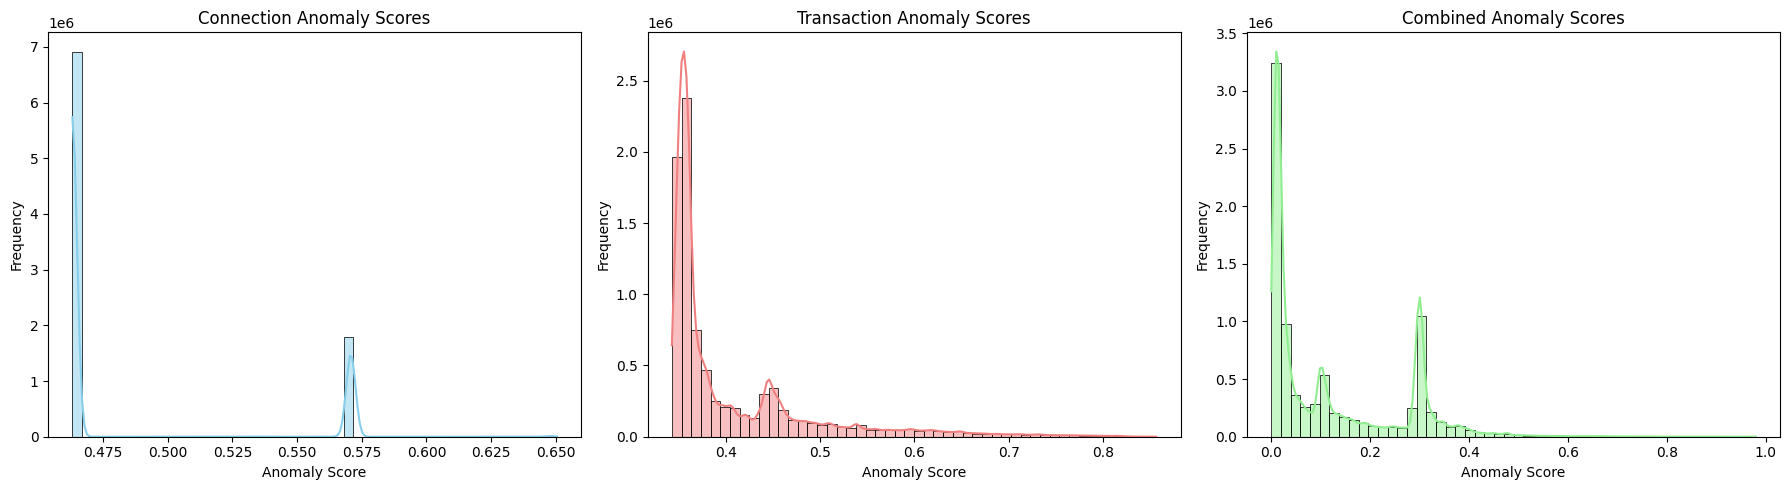

✅ Visualization saved


In [23]:
# Plot distributions
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(conn_all_p, bins=50, kde=True, color='skyblue')
plt.title('Connection Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(trx_all_p, bins=50, kde=True, color='lightcoral')
plt.title('Transaction Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(combined_norm_p, bins=50, kde=True, color='lightgreen')
plt.title('Combined Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'polars_score_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved")

## Step 13: Summary Report

In [24]:
print("\n" + "="*80)
print("FRAUD DETECTION PIPELINE SUMMARY (POLARS VERSION)")
print("="*80)
print(f"\n📊 Data Summary:")
print(f"  Total CIFs processed: {len(all_cifs):,}")
print(f"  Labeled (with ground truth): {np.sum(y != -1):,}")
print(f"  Suspected fraud (labeled): {np.sum(y == 1):,}")
print(f"  Non-fraud (labeled): {np.sum(y == 0):,}")
print(f"\n📈 Model Performance:")
print(f"  Connection Model - AUC: {conn_sup_res['auc']:.4f}, AP: {conn_sup_res['ap']:.4f}, F1: {conn_sup_res['f1']:.4f}")
print(f"  Transaction Model - AUC: {trx_sup_res['auc']:.4f}, AP: {trx_sup_res['ap']:.4f}, F1: {trx_sup_res['f1']:.4f}")
print(f"  Combined Model - AUC: {comb_sup_res['auc']:.4f}, AP: {comb_sup_res['ap']:.4f}, F1: {comb_sup_res['f1']:.4f}")
print(f"\n🎯 Predictions:")
print(f"  High-risk fraudsters (combined score > 0.5): {len(pred_df_fraud):,}")
print(f"\n💾 Output Files:")
print(f"  - {output_dir}/unsupervised_polars_predictions_all.csv")
print(f"  - {output_dir}/unsupervised_polars_predictions_fraud_only.csv")
print(f"  - {output_dir}/unsupervised_polars_models.joblib")
print(f"  - {output_dir}/polars_score_distributions.png")
print("\n✅ Pipeline Complete!")
print("="*80)


FRAUD DETECTION PIPELINE SUMMARY (POLARS VERSION)

📊 Data Summary:
  Total CIFs processed: 8,729,054
  Labeled (with ground truth): 6,194,151
  Suspected fraud (labeled): 407,757
  Non-fraud (labeled): 5,786,394

📈 Model Performance:
  Connection Model - AUC: 0.4534, AP: 0.0628, F1: 0.1235
  Transaction Model - AUC: 0.6405, AP: 0.1434, F1: 0.1946
  Combined Model - AUC: 0.5682, AP: 0.0836, F1: 0.1446

🎯 Predictions:
  High-risk fraudsters (combined score > 0.5): 55,707

💾 Output Files:
  - /home/jupyterhub/work/SIDIK/unsupervised_polars_output/unsupervised_polars_predictions_all.csv
  - /home/jupyterhub/work/SIDIK/unsupervised_polars_output/unsupervised_polars_predictions_fraud_only.csv
  - /home/jupyterhub/work/SIDIK/unsupervised_polars_output/unsupervised_polars_models.joblib
  - /home/jupyterhub/work/SIDIK/unsupervised_polars_output/polars_score_distributions.png

✅ Pipeline Complete!


In [27]:
pred_fraud_polars

cif,connection_score_raw,transaction_score_raw,connection_proba_norm,transaction_proba_norm,combined_proba,connection_pred,transaction_pred,combined_pred,real_label
str,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""1000003160""",0.570775,0.691008,0.574851,0.677739,0.626295,1,1,1,-1
"""1000005056""",0.647823,0.751607,0.9862,0.795765,0.890983,1,1,1,0
"""1000005335""",0.647823,0.694662,0.9862,0.684854,0.835527,1,1,1,0
"""1000008454""",0.647823,0.76828,0.9862,0.828239,0.90722,1,1,1,0
"""1000010638""",0.647823,0.713567,0.9862,0.721675,0.853937,1,1,1,0
…,…,…,…,…,…,…,…,…,…
"""9100791885""",0.570775,0.648552,0.574851,0.595047,0.584949,1,1,1,0
"""9100791990""",0.570775,0.721986,0.574851,0.738073,0.656462,1,1,1,0
"""9100792460""",0.570775,0.721191,0.574851,0.736525,0.655688,1,1,1,0


In [31]:
pred_fraud_polars = pred_fraud_polars.with_columns(
    current_date = date.today()
)

In [40]:
import sys, os
sys.path.append(os.path.join('/home/module'))
import pandas as pd

import math
import pandas as pd
from google.cloud import bigquery
from google.oauth2 import service_account

# setup BigQuery client sekali
key_path = 'jupyter-pgd-prod-data-analytics-0fa0e01ee70a.json'
credentials = service_account.Credentials.from_service_account_file(
    key_path, scopes=["https://www.googleapis.com/auth/cloud-platform"],
)
bq_client = bigquery.Client(credentials=credentials, project=credentials.project_id)

In [41]:
def import_sum_symptom_polars(df: pl.DataFrame, dest_table: str):

    if df.is_empty():
        print(f"DataFrame is empty. Skipping upload to {dest_table}\n")
        return 

    # Mapping Polars dtypes to BQ types
    # Polars dtypes are objects, not strings, so we map the classes/types directly
    dtype_to_bq = {
        pl.String: 'STRING',
        pl.Int64: 'INT64',
        pl.Int32: 'INT64',
        pl.Float64: 'FLOAT64',
        pl.Float32: 'FLOAT64',
        pl.Boolean: 'BOOLEAN',
        pl.Datetime: 'TIMESTAMP',
        pl.Date: 'DATE',
    }

    # Build schema dynamically
    schema = []
    for col_name, pl_type in df.schema.items():
        # Handle cases where the type might be an instance (like Datetime)
        base_type = type(pl_type) if not isinstance(pl_type, type) else pl_type
        
        bq_type = dtype_to_bq.get(base_type)
        
        if not bq_type:
            raise ValueError(f"Unknown Polars dtype '{pl_type}' for column '{col_name}'")
        
        schema.append(bigquery.SchemaField(col_name, bq_type))

    # Config load job
    job_config = bigquery.LoadJobConfig(
        schema=schema,
        write_disposition="WRITE_APPEND"
    )

    # Load to BQ
    # For Polars, we convert to a Pandas DF or use the Arrow stream for better speed.
    job = bq_client.load_table_from_dataframe(
        df.to_pandas(), # Polars to Pandas conversion
        dest_table, 
        job_config=job_config
    )
    
    job.result()
    print(f"Loaded {job.output_rows} rows to {dest_table}")

In [42]:
target_table = "pgd-dev-data-analytics.datamart_audit.dm_dt_sidik_ml_customer"

In [43]:
import_sum_symptom_polars(pred_fraud_polars, target_table)

Loaded 55707 rows to pgd-dev-data-analytics.datamart_audit.dm_dt_sidik_ml_customer
